In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Car_Price.csv")

In [3]:
df.head()

,Brand,Model,Year,Selling_Price,KM_Driven,Fuel,Seller_Type,Transmission,Owner
0,Maruti,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Brand          4340 non-null   str  
 1   Model          4340 non-null   str  
 2   Year           4340 non-null   int64
 3   Selling_Price  4340 non-null   int64
 4   KM_Driven      4340 non-null   int64
 5   Fuel           4340 non-null   str  
 6   Seller_Type    4340 non-null   str  
 7   Transmission   4340 non-null   str  
 8   Owner          4340 non-null   str  
dtypes: int64(3), str(6)
memory usage: 305.3 KB


In [5]:
df.describe()

,Year,Selling_Price,KM_Driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


## Clean duplicates & check nulls

In [6]:
df.duplicated().sum()

np.int64(763)

In [7]:
df = df.drop_duplicates(keep='first')

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Brand            0
Model            0
Year             0
Selling_Price    0
KM_Driven        0
Fuel             0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

## Feature engineering
Scale KM_Driven and Selling_Price to thousands, but **keep them as floats** (no premature `astype(int)` — that was silently truncating real values).

In [10]:
df['KM_Driven'] = df['KM_Driven'] / 1000
df['Selling_Price'] = df['Selling_Price'] / 1000
df.head()

,Brand,Model,Year,Selling_Price,KM_Driven,Fuel,Seller_Type,Transmission,Owner
0,Maruti,Maruti 800 AC,2007,60.0,70.0,Petrol,Individual,Manual,First Owner
1,Maruti,Maruti Wagon R LXI Minor,2007,135.0,50.0,Petrol,Individual,Manual,First Owner
2,Hyundai,Hyundai Verna 1.6 SX,2012,600.0,100.0,Diesel,Individual,Manual,First Owner
3,Datsun,Datsun RediGO T Option,2017,250.0,46.0,Petrol,Individual,Manual,First Owner
4,Honda,Honda Amaze VX i-DTEC,2014,450.0,141.0,Diesel,Individual,Manual,Second Owner


`Model` has 1,491 unique values — one-hot encoding it would explode the feature space and mostly add noise, so we drop it.

In [11]:
df = df.drop(columns=['Model'])

One-hot encode categoricals with `drop_first=True` to avoid the dummy variable trap (perfectly collinear dummy columns).

In [12]:
df = pd.get_dummies(df, drop_first=True)
df = df.astype(float)   # dummies -> 0/1 floats; safe now, nothing truncated
df.head()

,Year,Selling_Price,KM_Driven,Brand_Audi,Brand_BMW,Brand_Chevrolet,Brand_Daewoo,Brand_Datsun,Brand_Fiat,Brand_Force,...,Fuel_Electric,Fuel_LPG,Fuel_Petrol,Seller_Type_Individual,Seller_Type_Trustmark Dealer,Transmission_Manual,Owner_Fourth & Above Owner,Owner_Second Owner,Owner_Test Drive Car,Owner_Third Owner
0,2007.0,60.0,70.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2007.0,135.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2012.0,600.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,2017.0,250.0,46.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2014.0,450.0,141.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


## Split BEFORE scaling (avoid data leakage)

In [13]:
X = df.drop(columns=['Selling_Price'])
y = df['Selling_Price']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Fit the scaler **only on the training set**, then apply it to both train and test. Fitting on the full dataset before splitting leaks test-set statistics into training.

In [15]:
from sklearn.preprocessing import StandardScaler

numeric_col = ['Year', 'KM_Driven']
scaler = StandardScaler()

X_train[numeric_col] = scaler.fit_transform(X_train[numeric_col])
X_test[numeric_col] = scaler.transform(X_test[numeric_col])

## Train the model

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_pred = model.predict(X_test)

## Evaluate
R² alone doesn't tell you much about real-world error, so add MAE and RMSE in actual currency units (thousands, matching Selling_Price).

In [18]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R^2:  {r2:.4f}")
print(f"MAE:  {mae:.2f}  (thousands)")
print(f"RMSE: {rmse:.2f}  (thousands)")

R^2:  0.5384
MAE:  180.19  (thousands)
RMSE: 385.61  (thousands)


## Residual plot
Checks whether errors are patterned (a sign linear regression is missing nonlinearity) or reasonably random.

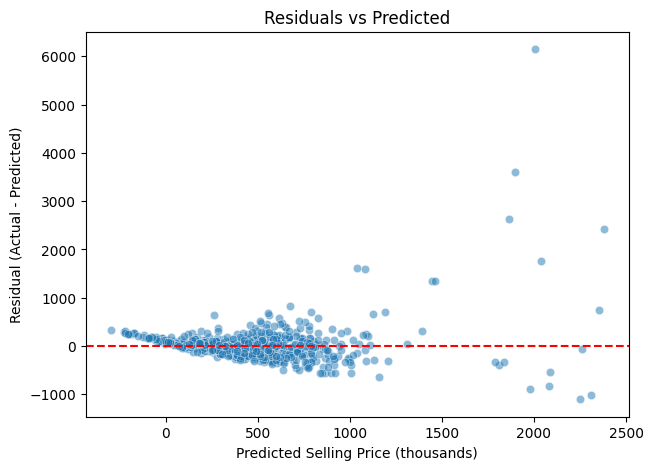

In [19]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Selling Price (thousands)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals vs Predicted')
plt.show()